# Spatio-Temporal PM₂.5 Forecasting — Option B (Two-Stage Transfer Learning)

## Architecture Overview

**The core problem:** Traffic data only exists for ~9.5 months (Jul 2017 – Apr 2018),
but weather/PM₂.5 data spans 11 years (2014–2025). We cannot jointly train on the
full timeline because traffic is absent for most of it.

**The solution — two-stage transfer learning:**

**Stage 1 — Traffic-Aware Spatial Encoder (trained on overlapping window)**
- Input: 24 traffic sensor nodes, each with a per-node LSTM encoder
- Spatial message passing: GCN on the LSTM hidden states → graph-level embedding
- Target: predict PM₂.5 for the overlap period (Jul 2017 – Apr 2018)
- Output: a frozen `SpatialEncoder` that has learned how Bath's road network
  relates to pollution levels

**Stage 2 — Full-Timeline Forecaster (trained on 11 years)**
- Input: weather + meteo covariates + PM₂.5 history (no traffic needed)
- Uses the frozen `SpatialEncoder` weights as a **learned spatial prior**:
  the graph embedding is computed from *synthetic* node features derived from
  hour-of-day and weather proxies (since live traffic isn't available)
- The idea: the encoder has learned spatial co-variation patterns between
  road segments; even when fed proxy features, it injects a spatial inductive
  bias that a purely temporal model lacks
- Output: 24-hour PM₂.5 forecast for the city sensor

**At inference (MPC):** Only weather + PM₂.5 history is needed. The frozen encoder
provides the spatial regularisation implicitly.

## 0. Imports & Config

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import networkx as nx
import geopy.distance
from torch_geometric.data import Data

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Sliding window config (consistent with prior notebooks) ──────────────────
LOOKBACK       = 72   # 3 days history
FORECAST       = 24   # 24-hour horizon
BATCH_SIZE     = 32
STAGE1_EPOCHS  = 60
STAGE2_EPOCHS  = 80

/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/data/ll2531/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 1. Load Data

In [2]:
with open('processed_data_pkl/imputed_training_data.pkl', 'rb') as f:
    traffic_dic = pickle.load(f)

with open('processed_data_pkl/weather_global_2014_2025.pkl', 'rb') as f:
    weather = pickle.load(f)

air_qual = pd.read_csv('online_data/air_qual/air_qual.csv')
air_qual.drop(columns=['aerosol_optical_depth ()', 'dust (μg/m³)'], errors='ignore', inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(drop=True, inplace=True)
air_qual['time'] = pd.to_datetime(air_qual['time'], errors='coerce')

weather['timestamp'] = pd.to_datetime(weather['timestamp'], errors='coerce')

# ── Full weather + PM2.5 timeline (2014-2025) ─────────────────────────────────
full_df = pd.merge(weather, air_qual, left_on='timestamp', right_on='time', how='inner')
full_df = full_df.sort_values('timestamp').set_index('timestamp').asfreq('h')
full_df.drop(columns=['time'], errors='ignore', inplace=True)

print(f'Full timeline: {full_df.index.min()} → {full_df.index.max()}')
print(f'Total hourly rows: {len(full_df):,}')

TARGET_COL = 'pm2_5 (μg/m³)'
WEATHER_FEATURE_COLS = [
    'temperature_2m (°C)',
    'surface_pressure (hPa)',
    'wind_speed_100m (km/h)',
    'wind_direction_100m (°)',
    'precipitation (mm)',
    'relative_humidity_2m (%)',
    'cloud_cover (%)',
]
WEATHER_FEATURE_COLS = [c for c in WEATHER_FEATURE_COLS if c in full_df.columns]
print(f'Weather features used: {WEATHER_FEATURE_COLS}')

Full timeline: 2016-01-01 00:00:00 → 2025-12-31 23:00:00
Total hourly rows: 87,672
Weather features used: ['temperature_2m (°C)', 'surface_pressure (hPa)', 'wind_speed_100m (km/h)', 'wind_direction_100m (°)', 'precipitation (mm)', 'relative_humidity_2m (%)', 'cloud_cover (%)']


## 2. Build Traffic Graph (same as original notebook)

In [3]:
G = nx.DiGraph()

for sensor_id, directions in traffic_dic.items():
    for direction, df in directions.items():
        origin_lat = df['latitude'].iloc[0]
        origin_lon = df['longitude'].iloc[0]
        G.add_node(sensor_id, pos=(origin_lon, origin_lat))
        for sensor_id_2, directions_2 in traffic_dic.items():
            if sensor_id == sensor_id_2:
                continue
            for direction_2, df_2 in directions_2.items():
                target_lat = df_2['latitude'].iloc[0]
                target_lon = df_2['longitude'].iloc[0]
                dist = geopy.distance.geodesic(
                    (origin_lat, origin_lon), (target_lat, target_lon)
                ).m
                if dist < 1000:
                    G.add_edge(sensor_id, sensor_id_2, distance=dist)

manual_edges = [
    (11,23),(9,22),(9,23),(1,12),(2,14),(3,14),(4,14),(5,15),
    (8,20),(6,19),(6,16),(8,19),(7,20),(7,19),(6,5),(17,14),(15,14),(16,14)
]
node_positions = nx.get_node_attributes(G, 'pos')
for source, target in manual_edges:
    lon1, lat1 = node_positions[source]
    lon2, lat2 = node_positions[target]
    dist = geopy.distance.geodesic((lat1, lon1), (lat2, lon2)).m
    G.add_edge(source, target, distance=dist)

sensor_ids = list(G.nodes())
node_map   = {sid: idx for idx, sid in enumerate(sensor_ids)}
NUM_NODES  = len(sensor_ids)

edge_list = []
for u, v in G.edges():
    edge_list.append([node_map[u], node_map[v]])
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

print(f'Graph: {NUM_NODES} nodes, {edge_index.shape[1]} edges')

Graph: 24 nodes, 62 edges


## 3. Build Traffic Feature Tensor (normalised per feature)

In [4]:
# ── Identify traffic feature columns ─────────────────────────────────────────
sample_df      = list(traffic_dic[sensor_ids[0]].values())[0]
exclude_cols   = ['latitude', 'longitude', 'timestamp', 'time', 'miles', 'avtime', 'hour']
traffic_feat_cols = [c for c in sample_df.columns if c not in exclude_cols]
TRAFFIC_FEAT_DIM  = len(traffic_feat_cols)
print(f'Traffic features per node: {traffic_feat_cols}')

# ── Build raw (T, N, F) tensor and fit scalers per feature across all nodes ──
# We need a single timestamp axis — use sensor_ids[0] as the reference index
ref_df     = list(traffic_dic[sensor_ids[0]].values())[0].copy()
ref_df['timestamp'] = pd.to_datetime(ref_df['timestamp'])
ref_df     = ref_df.set_index('timestamp').sort_index()
T_TRAFFIC  = len(ref_df)
traffic_timestamps = ref_df.index

# Build (T, N, F) raw array
traffic_raw = np.zeros((T_TRAFFIC, NUM_NODES, TRAFFIC_FEAT_DIM), dtype=np.float32)
for sensor_id in sensor_ids:
    nidx = node_map[sensor_id]
    df   = list(traffic_dic[sensor_id].values())[0].copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df   = df.set_index('timestamp').sort_index()
    df['count_imputed'] = df['count_imputed'].astype(float)
    traffic_raw[:, nidx, :] = df[traffic_feat_cols].values

# ── Fit MinMaxScaler on (T*N, F) so scale is shared across nodes ─────────────
flat = traffic_raw.reshape(-1, TRAFFIC_FEAT_DIM)
traffic_scaler = MinMaxScaler()
flat_scaled    = traffic_scaler.fit_transform(flat)
traffic_scaled = flat_scaled.reshape(T_TRAFFIC, NUM_NODES, TRAFFIC_FEAT_DIM)

# Add cyclic time features to each node identically
hour_sin = np.sin(2 * np.pi * traffic_timestamps.hour / 24.0).values.astype(np.float32)
hour_cos = np.cos(2 * np.pi * traffic_timestamps.hour / 24.0).values.astype(np.float32)
day_sin  = np.sin(2 * np.pi * traffic_timestamps.dayofweek / 7.0).values.astype(np.float32)
day_cos  = np.cos(2 * np.pi * traffic_timestamps.dayofweek / 7.0).values.astype(np.float32)
time_feats = np.stack([hour_sin, hour_cos, day_sin, day_cos], axis=1)  # (T, 4)
time_feats = np.tile(time_feats[:, np.newaxis, :], (1, NUM_NODES, 1))  # (T, N, 4)

traffic_final = np.concatenate([traffic_scaled, time_feats], axis=2)  # (T, N, F+4)
NODE_FEAT_DIM = traffic_final.shape[2]

print(f'Traffic tensor shape (T, N, F): {traffic_final.shape}')
print(f'Traffic date range: {traffic_timestamps[0]} → {traffic_timestamps[-1]}')

Traffic features per node: ['count', 'speed(mph)', 'TravelTime', 'hour_sin', 'hour_cos', 'is_weekend', 'count_imputed']
Traffic tensor shape (T, N, F): (6950, 24, 11)
Traffic date range: 2017-07-02 22:00:00 → 2018-04-18 11:00:00


## 4. Identify Overlapping Window & Build Stage 1 Dataset

Traffic exists Jul 2017 – Apr 2018.  The Stage 1 dataset aligns PM₂.5 targets
with the traffic tensor on this window.

In [5]:
# ── PM2.5 target series aligned to the full_df index ─────────────────────────
full_df_clean = full_df[[TARGET_COL] + WEATHER_FEATURE_COLS].copy().dropna()

# Overlap = timestamps present in BOTH traffic and PM2.5 series
overlap_mask = full_df_clean.index.isin(traffic_timestamps)
overlap_df   = full_df_clean[overlap_mask].copy()
print(f'Overlap window: {overlap_df.index.min()} → {overlap_df.index.max()}')
print(f'Overlap rows: {len(overlap_df):,}')

# ── Scale PM2.5 and weather for Stage 1 ──────────────────────────────────────
# Fit scalers on the FULL timeline so Stage 2 uses the same scale
pm25_scaler = MinMaxScaler()
weather_scaler = MinMaxScaler()

pm25_scaler.fit(full_df_clean[[TARGET_COL]].values)
weather_scaler.fit(full_df_clean[WEATHER_FEATURE_COLS].values)

# Scale overlap subset
overlap_pm25_scaled    = pm25_scaler.transform(overlap_df[[TARGET_COL]].values).flatten()
overlap_weather_scaled = weather_scaler.transform(overlap_df[WEATHER_FEATURE_COLS].values)

# Align traffic tensor to the overlap index
# Build a lookup from timestamp → traffic row index
traffic_ts_series = pd.Series(range(T_TRAFFIC), index=traffic_timestamps)
overlap_traffic_indices = traffic_ts_series.reindex(overlap_df.index).values
valid_mask = ~np.isnan(overlap_traffic_indices)
overlap_df_valid = overlap_df[valid_mask].copy()
overlap_traffic_indices = overlap_traffic_indices[valid_mask].astype(int)
overlap_pm25_scaled    = overlap_pm25_scaled[valid_mask]
overlap_weather_scaled = overlap_weather_scaled[valid_mask]

# Slice traffic tensor to the overlap window
traffic_overlap = traffic_final[overlap_traffic_indices]  # (T_overlap, N, F)
print(f'Traffic overlap tensor shape: {traffic_overlap.shape}')

Overlap window: 2017-07-02 22:00:00 → 2018-04-18 11:00:00
Overlap rows: 6,950
Traffic overlap tensor shape: (6950, 24, 11)


In [6]:
full_df_clean

,pm2_5 (μg/m³),temperature_2m (°C),surface_pressure (hPa),wind_speed_100m (km/h),wind_direction_100m (°),precipitation (mm),relative_humidity_2m (%),cloud_cover (%)
timestamp,,,,,,,,
2016-01-01 00:00:00,5.9,3.3,1011.8,22.3,247,0.0,88,0
2016-01-01 01:00:00,8.6,2.3,1012.1,16.8,242,0.0,91,14
2016-01-01 02:00:00,12.6,1.3,1012.1,15.9,219,0.0,92,1
2016-01-01 03:00:00,10.3,0.5,1012.8,19.1,200,0.0,94,76
2016-01-01 04:00:00,9.1,0.3,1012.9,19.7,188,0.0,94,100
...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,12.6,-1.1,1017.5,23.3,266,0.0,97,77
2025-12-31 20:00:00,12.0,-1.0,1016.9,24.7,271,0.0,95,21
2025-12-31 21:00:00,11.6,-0.9,1015.9,26.3,269,0.0,93,31


In [7]:
import plotly.graph_objects as go
import pandas as pd

# 1. Assuming you have a DataFrame 'df' with a datetime index or column
# Let's create a quick dummy example (Replace this with your actual dataframe)
# df = pd.read_csv('your_data.csv', parse_dates=['timestamp_column'])

# 2. Create the interactive figure
fig = go.Figure()

# 3. Add your time series line
fig.add_trace(
    go.Scatter(
        x=full_df_clean.index,
        y=full_df_clean['pm2_5 (μg/m³)'],
        mode='lines',
        name='Observed Values',
        line=dict(color='#1f77b4', width=2),
        hovertemplate='<b>Date:</b> %{x}<br><b>Value:</b> %{y:.3f}<extra></extra>'
    )
)

# 4. Add interactive range sliders and selectors for easy zooming
fig.update_layout(
    title='Interactive Time Series Analysis',
    xaxis_title='Timeline',
    yaxis_title='Value',
    hovermode='x unified',
    template='plotly_white',
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1d", step="day", stepmode="backward"),
                dict(count=7, label="1w", step="day", stepmode="backward"),
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),  # Minimap at the bottom to slide/zoom
        type="date"
    )
)

# 5. Render the plot
fig.show()

## 5. Stage 1 Model Architecture

```
Input: (batch, N, T, F)  — traffic features per node
  │
  ├─ Per-node LSTM encoder  →  (batch, N, hidden)
  │
  ├─ GCN layer 1  +  ReLU   →  (batch, N, gcn_hidden)
  ├─ GCN layer 2  +  ReLU   →  (batch, N, gcn_hidden)
  │
  ├─ Global mean pool        →  (batch, gcn_hidden)  [graph-level embedding]
  │
  └─ FC head                 →  (batch, 24)  [24-hour PM2.5 forecast]
```

The `SpatialEncoder` (per-node LSTM + GCN) is the component that will be
frozen and reused in Stage 2.

In [8]:
class NodeLSTMEncoder(nn.Module):
    """Encode each node's time series independently with a shared LSTM."""
    def __init__(self, input_dim, hidden_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.hidden_dim = hidden_dim

    def forward(self, x):
        # x: (batch * N, T, F)
        _, (hn, _) = self.lstm(x)
        return hn[-1]  # (batch * N, hidden_dim)


class SpatialEncoder(nn.Module):
    """
    Per-node LSTM → GCN → graph-level embedding.
    This is the component that gets frozen in Stage 2.
    """
    def __init__(self, node_feat_dim, lstm_hidden, gcn_hidden, num_nodes,
                 lstm_layers=2, dropout=0.2):
        super().__init__()
        self.num_nodes   = num_nodes
        self.lstm_hidden = lstm_hidden
        self.node_encoder = NodeLSTMEncoder(node_feat_dim, lstm_hidden, lstm_layers, dropout)
        self.gcn1    = GCNConv(lstm_hidden, gcn_hidden)
        self.gcn2    = GCNConv(gcn_hidden, gcn_hidden)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.out_dim = gcn_hidden

    def forward(self, traffic_x, edge_index):
        # traffic_x: (batch, N, T, F)
        batch, N, T, F = traffic_x.shape
        # Reshape to process all nodes across all batch items together
        x_flat = traffic_x.view(batch * N, T, F)
        node_emb = self.node_encoder(x_flat)          # (batch*N, lstm_hidden)
        node_emb = node_emb.view(batch, N, -1)        # (batch, N, lstm_hidden)

        # Apply GCN per sample in the batch (edge_index is shared)
        graph_embs = []
        for b in range(batch):
            g = node_emb[b]                           # (N, lstm_hidden)
            g = self.relu(self.gcn1(g, edge_index))
            g = self.dropout(g)
            g = self.relu(self.gcn2(g, edge_index))   # (N, gcn_hidden)
            g = g.mean(dim=0)                         # (gcn_hidden,) — global mean pool
            graph_embs.append(g)

        return torch.stack(graph_embs, dim=0)          # (batch, gcn_hidden)


class Stage1Model(nn.Module):
    """Stage 1: Traffic → GCN embedding → 24-hour PM2.5 forecast."""
    def __init__(self, node_feat_dim, lstm_hidden, gcn_hidden, num_nodes,
                 forecast_steps, lstm_layers=2, dropout=0.2):
        super().__init__()
        self.spatial_encoder = SpatialEncoder(
            node_feat_dim, lstm_hidden, gcn_hidden, num_nodes, lstm_layers, dropout
        )
        self.head = nn.Sequential(
            nn.Linear(gcn_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, forecast_steps)
        )

    def forward(self, traffic_x, edge_index):
        graph_emb = self.spatial_encoder(traffic_x, edge_index)
        return self.head(graph_emb)  # (batch, forecast_steps)

## 6. Stage 1 Dataset & DataLoader

In [9]:
class Stage1Dataset(Dataset):
    """
    Sliding-window dataset over the overlap period.
    Returns:
        traffic_x : (N, T, F)  — per-node traffic features for the lookback window
        y         : (forecast_steps,)  — scaled PM2.5 target
    """
    def __init__(self, traffic_tensor, pm25_series, lookback, forecast_steps):
        self.traffic   = torch.tensor(traffic_tensor, dtype=torch.float32)  # (T, N, F)
        self.pm25      = torch.tensor(pm25_series, dtype=torch.float32)     # (T,)
        self.lookback  = lookback
        self.forecast  = forecast_steps
        self.n_samples = len(pm25_series) - lookback - forecast_steps + 1

    def __len__(self):
        return max(self.n_samples, 0)

    def __getitem__(self, idx):
        # traffic_x shape: (N, T, F)  — transpose from (T, N, F)
        traffic_x = self.traffic[idx : idx + self.lookback].permute(1, 0, 2)
        y = self.pm25[idx + self.lookback : idx + self.lookback + self.forecast]
        return traffic_x, y


s1_dataset = Stage1Dataset(
    traffic_tensor  = traffic_overlap,
    pm25_series     = overlap_pm25_scaled,
    lookback        = LOOKBACK,
    forecast_steps  = FORECAST
)

s1_split     = int(len(s1_dataset) * 0.8)
s1_train     = Subset(s1_dataset, list(range(s1_split)))
s1_test      = Subset(s1_dataset, list(range(s1_split, len(s1_dataset))))
s1_train_loader = DataLoader(s1_train, batch_size=BATCH_SIZE, shuffle=True)
s1_test_loader  = DataLoader(s1_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Stage 1 samples — train: {len(s1_train)}, test: {len(s1_test)}')

Stage 1 samples — train: 5484, test: 1371


## 7. Stage 1 Training

In [10]:
stage1_model = Stage1Model(
    node_feat_dim  = NODE_FEAT_DIM,
    lstm_hidden    = 64,
    gcn_hidden     = 64,
    num_nodes      = NUM_NODES,
    forecast_steps = FORECAST,
    lstm_layers    = 2,
    dropout        = 0.2
).to(DEVICE)

s1_optimizer = optim.Adam(stage1_model.parameters(), lr=1e-3)
s1_scheduler = optim.lr_scheduler.ReduceLROnPlateau(s1_optimizer, patience=5, factor=0.5)
s1_criterion = nn.MSELoss()
s1_edge_index = edge_index.to(DEVICE)

best_s1_val_loss = float('inf')
s1_train_losses, s1_val_losses = [], []

print('=== Stage 1 Training: Traffic-Aware Spatial Encoder ===')
for epoch in range(1, STAGE1_EPOCHS + 1):
    # --- Train ---
    stage1_model.train()
    train_loss = 0.0
    for traffic_x, y in s1_train_loader:
        traffic_x, y = traffic_x.to(DEVICE), y.to(DEVICE)
        s1_optimizer.zero_grad(set_to_none=True)
        pred = stage1_model(traffic_x, s1_edge_index)
        loss = s1_criterion(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(stage1_model.parameters(), 1.0)
        s1_optimizer.step()
        train_loss += loss.item() * traffic_x.size(0)
    train_loss /= len(s1_train_loader.dataset)
    s1_train_losses.append(train_loss)

    # --- Validate ---
    stage1_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for traffic_x, y in s1_test_loader:
            traffic_x, y = traffic_x.to(DEVICE), y.to(DEVICE)
            pred = stage1_model(traffic_x, s1_edge_index)
            val_loss += s1_criterion(pred, y).item() * traffic_x.size(0)
    val_loss /= len(s1_test_loader.dataset)
    s1_val_losses.append(val_loss)
    s1_scheduler.step(val_loss)

    if val_loss < best_s1_val_loss:
        best_s1_val_loss = val_loss
        torch.save(stage1_model.state_dict(), 'models_saved/5b_stage1_spatial_encoder.pt')

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{STAGE1_EPOCHS} | Train MSE: {train_loss:.5f} | Val MSE: {val_loss:.5f}')

# Load best weights
stage1_model.load_state_dict(torch.load('models_saved/5b_stage1_spatial_encoder.pt'))
print(f'\nBest Stage 1 val MSE: {best_s1_val_loss:.5f}')

=== Stage 1 Training: Traffic-Aware Spatial Encoder ===
Epoch  10/60 | Train MSE: 0.00436 | Val MSE: 0.00951
Epoch  20/60 | Train MSE: 0.00411 | Val MSE: 0.00952
Epoch  30/60 | Train MSE: 0.00406 | Val MSE: 0.00942
Epoch  40/60 | Train MSE: 0.00404 | Val MSE: 0.00941
Epoch  50/60 | Train MSE: 0.00404 | Val MSE: 0.00944
Epoch  60/60 | Train MSE: 0.00403 | Val MSE: 0.00944

Best Stage 1 val MSE: 0.00930


## 8. Stage 1 Evaluation & Loss Curves

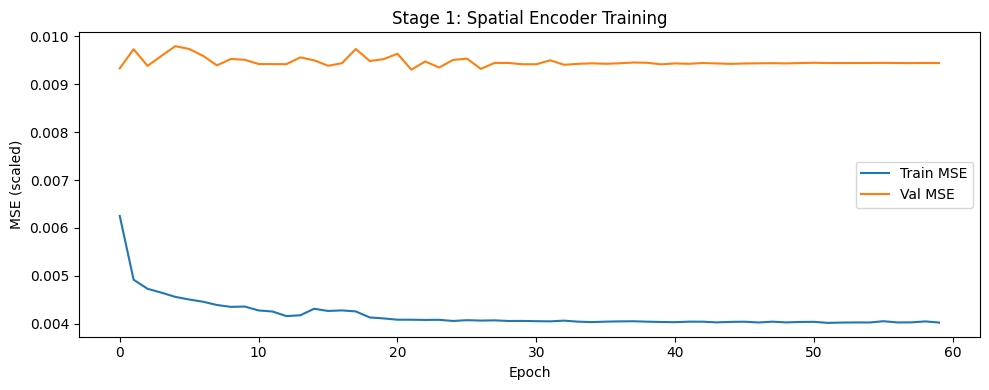


=== Stage 1 Test Results (Traffic-only window) ===
R²   : -0.2631
MAE  : 4.7958 μg/m³  (48.5%)
RMSE : 7.2240 μg/m³  (73.0%)


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(s1_train_losses, label='Train MSE')
ax.plot(s1_val_losses, label='Val MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (scaled)')
ax.set_title('Stage 1: Spatial Encoder Training')
ax.legend()
plt.tight_layout()
plt.show()

# ── Metrics on Stage 1 test set ───────────────────────────────────────────────
stage1_model.eval()
s1_preds, s1_trues = [], []
with torch.no_grad():
    for traffic_x, y in s1_test_loader:
        traffic_x = traffic_x.to(DEVICE)
        pred = stage1_model(traffic_x, s1_edge_index).cpu().numpy()
        s1_preds.append(pred)
        s1_trues.append(y.numpy())

s1_preds = np.concatenate(s1_preds).flatten()
s1_trues = np.concatenate(s1_trues).flatten()

# Inverse-transform to original μg/m³ scale
def inv_pm25(x_scaled):
    dummy = np.zeros((len(x_scaled), 1))
    dummy[:, 0] = x_scaled
    return pm25_scaler.inverse_transform(dummy)[:, 0]

s1_preds_orig = inv_pm25(s1_preds)
s1_trues_orig = inv_pm25(s1_trues)

s1_r2   = r2_score(s1_trues_orig, s1_preds_orig)
s1_mae  = mean_absolute_error(s1_trues_orig, s1_preds_orig)
s1_rmse = np.sqrt(mean_squared_error(s1_trues_orig, s1_preds_orig))
s1_mean = np.mean(s1_trues_orig)

print('\n=== Stage 1 Test Results (Traffic-only window) ===')
print(f'R²   : {s1_r2:.4f}')
print(f'MAE  : {s1_mae:.4f} μg/m³  ({s1_mae/s1_mean*100:.1f}%)')
print(f'RMSE : {s1_rmse:.4f} μg/m³  ({s1_rmse/s1_mean*100:.1f}%)')

## 9. Freeze Stage 1 Spatial Encoder

The `SpatialEncoder` has learned how Bath's road network co-varies with pollution.
We now freeze its weights so they act as a static learned prior in Stage 2.
The encoder's weights will not update during Stage 2 training.

In [12]:
frozen_encoder = stage1_model.spatial_encoder
frozen_encoder.eval()
for param in frozen_encoder.parameters():
    param.requires_grad = False

# Quick sanity check
total = sum(p.numel() for p in frozen_encoder.parameters())
frozen_count = sum(p.numel() for p in frozen_encoder.parameters() if not p.requires_grad)
print(f'SpatialEncoder — total params: {total:,}, frozen: {frozen_count:,}')

SpatialEncoder — total params: 61,312, frozen: 61,312


## 10. Synthetic Node Feature Generator

At Stage 2 inference (and for most of the 11-year training window) we have no
real traffic data.  We synthesise node features from:
- **Cyclic time encodings** (hour, day-of-week) — the strongest predictor of
  traffic volume
- **Weather proxies** (temperature, precipitation, wind speed) — modulate
  traffic behaviour
- **Node identity embedding** — a learnable per-node scalar so the frozen LSTM
  can distinguish nodes even without real counts

The frozen encoder therefore sees a *plausible* (albeit synthetic) traffic-like
input and produces a spatial embedding that acts as a learned inductive bias
rather than a precise traffic measurement.

In [13]:
class SyntheticNodeFeatureGenerator(nn.Module):
    """
    Learnable module that maps global context (time + weather) to per-node
    synthetic features compatible with the frozen SpatialEncoder input.

    Input  : (batch, T, weather_feat_dim)   — weather window
    Output : (batch, N, T, node_feat_dim)   — synthetic node features
    """
    def __init__(self, weather_feat_dim, node_feat_dim, num_nodes, hidden=32):
        super().__init__()
        self.num_nodes     = num_nodes
        self.node_feat_dim = node_feat_dim
        # Learnable per-node identity embedding (node_feat_dim,)
        self.node_emb = nn.Embedding(num_nodes, node_feat_dim)
        # Small MLP: projects weather → node_feat_dim (shared across nodes)
        self.weather_proj = nn.Sequential(
            nn.Linear(weather_feat_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, node_feat_dim)
        )

    def forward(self, weather_window):
        # weather_window: (batch, T, weather_feat_dim)
        batch, T, _ = weather_window.shape
        # Project each timestep in the window
        w_proj = self.weather_proj(weather_window)   # (batch, T, node_feat_dim)
        # Node identity bias: (N, node_feat_dim) → broadcast over (batch, T)
        node_ids = torch.arange(self.num_nodes, device=weather_window.device)
        n_bias   = self.node_emb(node_ids)           # (N, node_feat_dim)
        # Broadcast: (batch, T, F) + (N, F) → (batch, N, T, F)
        w_exp  = w_proj.unsqueeze(1).expand(batch, self.num_nodes, T, -1)
        nb_exp = n_bias.unsqueeze(0).unsqueeze(2).expand(batch, -1, T, -1)
        return torch.tanh(w_exp + nb_exp)            # (batch, N, T, node_feat_dim)

print('SyntheticNodeFeatureGenerator defined.')

SyntheticNodeFeatureGenerator defined.


## 11. Stage 2 Model Architecture

```
Inputs:
  weather_window   : (batch, T, W)   — weather + PM2.5 history
  time_context     : included in weather_window (hour_sin/cos etc.)

Forward pass:
  1. SyntheticNodeFeatureGenerator  →  (batch, N, T, F_node)
  2. Frozen SpatialEncoder          →  (batch, gcn_hidden)   [spatial prior]
  3. Transformer-LSTM backbone      →  (batch, d_model)      [temporal features]
  4. Concatenate [spatial | temporal]  →  (batch, gcn_hidden + d_model)
  5. FC fusion head                 →  (batch, 24)
```

In [14]:
class TransformerLSTMBackbone(nn.Module):
    """Same backbone architecture as used in notebooks 4.4–4.6."""
    def __init__(self, input_dim, d_model, nhead, num_transformer_layers,
                 hidden_dim, num_lstm_layers, seq_len, dropout=0.2):
        super().__init__()
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.pos_enc     = nn.Parameter(torch.zeros(1, seq_len, d_model))
        enc_layer        = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_transformer_layers)
        self.lstm        = nn.LSTM(
            input_size=d_model, hidden_size=hidden_dim,
            num_layers=num_lstm_layers, batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0.0
        )
        self.dropout     = nn.Dropout(dropout)
        self.out_dim     = hidden_dim

    def forward(self, x):
        x = self.input_proj(x) + self.pos_enc[:, :x.size(1), :]
        x = self.dropout(x)
        x = self.transformer(x)
        _, (hn, _) = self.lstm(x)
        return hn[-1]  # (batch, hidden_dim)


class Stage2Model(nn.Module):
    """
    Full-timeline forecaster that combines:
      - Frozen spatial encoder (traffic knowledge, inferred via synthetic features)
      - Transformer-LSTM temporal backbone (weather + PM2.5 history)
    """
    def __init__(self, weather_feat_dim, node_feat_dim, num_nodes,
                 frozen_encoder, gcn_hidden, seq_len,
                 d_model=64, nhead=4, n_transformer=2,
                 lstm_hidden=128, n_lstm=2,
                 forecast_steps=24, dropout=0.2):
        super().__init__()
        self.frozen_encoder = frozen_encoder  # weights already frozen
        self.synth_gen = SyntheticNodeFeatureGenerator(
            weather_feat_dim=weather_feat_dim,
            node_feat_dim=node_feat_dim,
            num_nodes=num_nodes
        )
        self.temporal_backbone = TransformerLSTMBackbone(
            input_dim=weather_feat_dim,
            d_model=d_model,
            nhead=nhead,
            num_transformer_layers=n_transformer,
            hidden_dim=lstm_hidden,
            num_lstm_layers=n_lstm,
            seq_len=seq_len,
            dropout=dropout
        )
        fused_dim = gcn_hidden + lstm_hidden
        self.fusion_head = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, forecast_steps)
        )

    def forward(self, weather_x, edge_index):
        # 1. Generate synthetic node features from weather window
        synth_nodes = self.synth_gen(weather_x)           # (batch, N, T, F_node)
        # 2. Pass through frozen spatial encoder
        with torch.no_grad():
            spatial_emb = self.frozen_encoder(synth_nodes, edge_index)  # (batch, gcn_hidden)
        # 3. Temporal backbone on raw weather window
        temporal_emb = self.temporal_backbone(weather_x)  # (batch, lstm_hidden)
        # 4. Fuse and predict
        fused = torch.cat([spatial_emb, temporal_emb], dim=-1)
        return self.fusion_head(fused)                    # (batch, forecast_steps)

print('Stage 2 architecture defined.')

Stage 2 architecture defined.


## 12. Stage 2 Dataset (Full 11-year Timeline)

In [15]:
# ── Add cyclic time encodings to the full weather feature set ─────────────────
full_df_clean = full_df[[TARGET_COL] + WEATHER_FEATURE_COLS].copy().dropna()
full_df_clean['hour_sin'] = np.sin(2 * np.pi * full_df_clean.index.hour / 24.0)
full_df_clean['hour_cos'] = np.cos(2 * np.pi * full_df_clean.index.hour / 24.0)
full_df_clean['day_sin']  = np.sin(2 * np.pi * full_df_clean.index.dayofweek / 7.0)
full_df_clean['day_cos']  = np.cos(2 * np.pi * full_df_clean.index.dayofweek / 7.0)
full_df_clean['month_sin'] = np.sin(2 * np.pi * full_df_clean.index.month / 12.0)
full_df_clean['month_cos'] = np.cos(2 * np.pi * full_df_clean.index.month / 12.0)

# Features fed to Stage 2 temporal backbone:
# PM2.5 history + weather + cyclic time
S2_FEAT_COLS = (
    [TARGET_COL] + WEATHER_FEATURE_COLS +
    ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
)
S2_FEAT_DIM = len(S2_FEAT_COLS)
print(f'Stage 2 feature cols ({S2_FEAT_DIM}): {S2_FEAT_COLS}')

# ── Scale Stage 2 features ────────────────────────────────────────────────────
# Train up to end of 2024; test on 2025
s2_train_raw = full_df_clean.loc[:'2024-12-31 23:00:00', S2_FEAT_COLS].copy()
s2_test_raw  = full_df_clean.loc['2025-01-01':'2025-01-31 23:00:00', S2_FEAT_COLS].copy()

s2_scaler = MinMaxScaler()
s2_train_scaled = s2_scaler.fit_transform(s2_train_raw.values)
s2_test_scaled  = s2_scaler.transform(s2_test_raw.values)

# PM2.5 target index within the scaled feature matrix (for inverse transform)
S2_TARGET_IDX = S2_FEAT_COLS.index(TARGET_COL)

print(f'Stage 2 train rows: {len(s2_train_scaled):,}')
print(f'Stage 2 test rows : {len(s2_test_scaled):,}')


class Stage2Dataset(Dataset):
    """Sliding-window over the full timeline; no traffic data required."""
    def __init__(self, feature_matrix, lookback, forecast_steps, target_idx):
        self.X          = torch.tensor(feature_matrix, dtype=torch.float32)
        self.lookback   = lookback
        self.forecast   = forecast_steps
        self.target_idx = target_idx
        self.n_samples  = len(feature_matrix) - lookback - forecast_steps + 1

    def __len__(self):
        return max(self.n_samples, 0)

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.lookback]                                    # (T, F)
        y = self.X[idx + self.lookback : idx + self.lookback + self.forecast, self.target_idx]  # (24,)
        return x, y


s2_train_ds = Stage2Dataset(s2_train_scaled, LOOKBACK, FORECAST, S2_TARGET_IDX)
s2_test_ds  = Stage2Dataset(s2_test_scaled,  LOOKBACK, FORECAST, S2_TARGET_IDX)
s2_train_loader = DataLoader(s2_train_ds, batch_size=BATCH_SIZE, shuffle=True)
s2_test_loader  = DataLoader(s2_test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Stage 2 samples — train: {len(s2_train_ds):,}, test: {len(s2_test_ds):,}')

Stage 2 feature cols (14): ['pm2_5 (μg/m³)', 'temperature_2m (°C)', 'surface_pressure (hPa)', 'wind_speed_100m (km/h)', 'wind_direction_100m (°)', 'precipitation (mm)', 'relative_humidity_2m (%)', 'cloud_cover (%)', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
Stage 2 train rows: 78,912
Stage 2 test rows : 744
Stage 2 samples — train: 78,817, test: 649


## 13. Stage 2 Training

In [16]:
stage2_model = Stage2Model(
    weather_feat_dim = S2_FEAT_DIM,
    node_feat_dim    = NODE_FEAT_DIM,
    num_nodes        = NUM_NODES,
    frozen_encoder   = frozen_encoder.to(DEVICE),
    gcn_hidden       = 64,   # must match Stage 1 gcn_hidden
    seq_len          = LOOKBACK,
    d_model          = 64,
    nhead            = 4,
    n_transformer    = 2,
    lstm_hidden      = 128,
    n_lstm           = 2,
    forecast_steps   = FORECAST,
    dropout          = 0.2
).to(DEVICE)

# Only trainable params: synth_gen + temporal_backbone + fusion_head
trainable_params = [p for p in stage2_model.parameters() if p.requires_grad]
print(f'Trainable params: {sum(p.numel() for p in trainable_params):,}')

# Adam with weight decay (L2 regularisation) to reduce overfitting
s2_optimizer = optim.Adam(trainable_params, lr=5e-4, weight_decay=1e-4)
s2_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    s2_optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6
)
s2_criterion = nn.MSELoss()
s2_edge_index = edge_index.to(DEVICE)

best_s2_val_loss = float('inf')
s2_train_losses, s2_val_losses = [], []

# Early stopping: stop if val loss does not improve for this many epochs
EARLY_STOP_PATIENCE = 10
epochs_no_improve   = 0

print('\n=== Stage 2 Training: Full-Timeline Forecaster ===')
for epoch in range(1, STAGE2_EPOCHS + 1):
    # --- Train ---
    stage2_model.train()
    train_loss = 0.0
    for weather_x, y in s2_train_loader:
        weather_x, y = weather_x.to(DEVICE), y.to(DEVICE)
        s2_optimizer.zero_grad(set_to_none=True)
        pred = stage2_model(weather_x, s2_edge_index)
        loss = s2_criterion(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(trainable_params, 1.0)
        s2_optimizer.step()
        train_loss += loss.item() * weather_x.size(0)
    train_loss /= len(s2_train_loader.dataset)
    s2_train_losses.append(train_loss)

    # --- Validate ---
    stage2_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for weather_x, y in s2_test_loader:
            weather_x, y = weather_x.to(DEVICE), y.to(DEVICE)
            pred = stage2_model(weather_x, s2_edge_index)
            val_loss += s2_criterion(pred, y).item() * weather_x.size(0)
    val_loss /= len(s2_test_loader.dataset)
    s2_val_losses.append(val_loss)
    s2_scheduler.step(val_loss)

    if val_loss < best_s2_val_loss:
        best_s2_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(stage2_model.state_dict(), 'models_saved/5b_stage2_full_model.pt')
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{STAGE2_EPOCHS} | Train MSE: {train_loss:.5f} | Val MSE: {val_loss:.5f}')

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no val improvement for {EARLY_STOP_PATIENCE} epochs)')
        break

stage2_model.load_state_dict(torch.load('models_saved/5b_stage2_full_model.pt'))
print(f'\nBest Stage 2 val MSE: {best_s2_val_loss:.5f}')

Trainable params: 365,867

=== Stage 2 Training: Full-Timeline Forecaster ===
Epoch  10/80 | Train MSE: 0.00306 | Val MSE: 0.00337

Early stopping at epoch 12 (no val improvement for 10 epochs)

Best Stage 2 val MSE: 0.00325


## 14. Stage 2 Evaluation

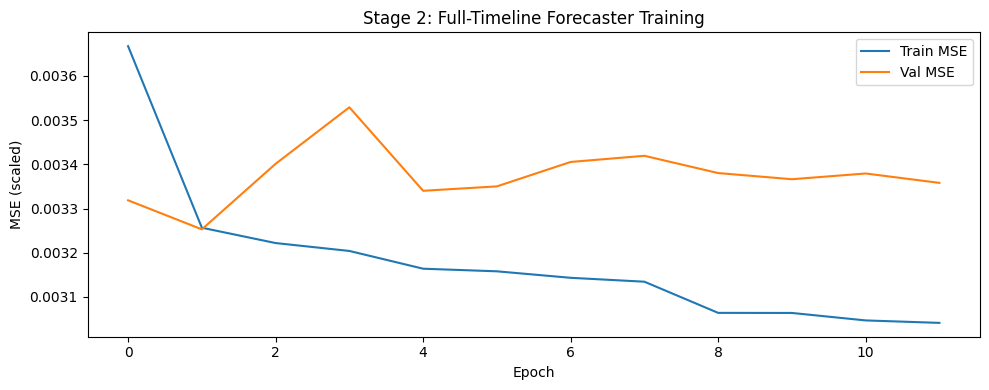


=== Stage 2 Test Results (Jan 2025, weather-only inference) ===
R²   : 0.5609
MAE  : 3.1959 μg/m³  (34.3%)
RMSE : 4.2719 μg/m³  (45.8%)

=== Comparison Table ===
Model                                          R²        MAE       RMSE
----------------------------------------------------------------------
Multivariate Transformer-LSTM (4.6)        0.6219     2.9127     3.9643
ST Option B Stage 1 (traffic window)      -0.2631     4.7958     7.2240
ST Option B Stage 2 (full timeline)        0.5609     3.1959     4.2719


In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(s2_train_losses, label='Train MSE')
ax.plot(s2_val_losses, label='Val MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (scaled)')
ax.set_title('Stage 2: Full-Timeline Forecaster Training')
ax.legend()
plt.tight_layout()
plt.show()

# ── Collect predictions ───────────────────────────────────────────────────────
stage2_model.eval()
s2_preds, s2_trues = [], []
with torch.no_grad():
    for weather_x, y in s2_test_loader:
        weather_x = weather_x.to(DEVICE)
        pred = stage2_model(weather_x, s2_edge_index).cpu().numpy()
        s2_preds.append(pred)
        s2_trues.append(y.numpy())

s2_preds = np.concatenate(s2_preds).flatten()
s2_trues = np.concatenate(s2_trues).flatten()

# ── Inverse-transform from MinMax scaled space back to μg/m³ ──────────────────
def inv_s2_target(x_scaled):
    """Inverse-transform the target column from the Stage 2 scaler."""
    n = len(x_scaled)
    dummy = np.zeros((n, S2_FEAT_DIM))
    dummy[:, S2_TARGET_IDX] = x_scaled
    return s2_scaler.inverse_transform(dummy)[:, S2_TARGET_IDX]

s2_preds_orig = inv_s2_target(s2_preds)
s2_trues_orig = inv_s2_target(s2_trues)

s2_r2   = r2_score(s2_trues_orig, s2_preds_orig)
s2_mae  = mean_absolute_error(s2_trues_orig, s2_preds_orig)
s2_rmse = np.sqrt(mean_squared_error(s2_trues_orig, s2_preds_orig))
s2_mean = np.mean(s2_trues_orig)

print('\n=== Stage 2 Test Results (Jan 2025, weather-only inference) ===')
print(f'R²   : {s2_r2:.4f}')
print(f'MAE  : {s2_mae:.4f} μg/m³  ({s2_mae/s2_mean*100:.1f}%)')
print(f'RMSE : {s2_rmse:.4f} μg/m³  ({s2_rmse/s2_mean*100:.1f}%)')

print('\n=== Comparison Table ===')
print(f'{"Model":<40} {"R²":>8} {"MAE":>10} {"RMSE":>10}')
print('-' * 70)
print(f'{"Multivariate Transformer-LSTM (4.6)":<40} {0.6219:>8.4f} {2.9127:>10.4f} {3.9643:>10.4f}')
print(f'{"ST Option B Stage 1 (traffic window)":<40} {s1_r2:>8.4f} {s1_mae:>10.4f} {s1_rmse:>10.4f}')
print(f'{"ST Option B Stage 2 (full timeline)":<40} {s2_r2:>8.4f} {s2_mae:>10.4f} {s2_rmse:>10.4f}')

## 15. Ablation: Spatial Prior vs No Spatial Prior

To justify the two-stage approach in the thesis, we train an identical Stage 2
model but with the spatial encoder output **zeroed out** (i.e., the frozen encoder
is bypassed).  If the full model outperforms the ablated version, we have evidence
that the spatial prior is contributing.

In [ ]:
class Stage2ModelNoSpatial(nn.Module):
    """Identical to Stage2Model but spatial branch is bypassed (zeroed)."""
    def __init__(self, weather_feat_dim, gcn_hidden, seq_len,
                 d_model=64, nhead=4, n_transformer=2,
                 lstm_hidden=128, n_lstm=2,
                 forecast_steps=24, dropout=0.2):
        super().__init__()
        self.temporal_backbone = TransformerLSTMBackbone(
            input_dim=weather_feat_dim,
            d_model=d_model, nhead=nhead,
            num_transformer_layers=n_transformer,
            hidden_dim=lstm_hidden,
            num_lstm_layers=n_lstm,
            seq_len=seq_len, dropout=dropout
        )
        # Spatial placeholder: zeros of same size as gcn_hidden
        fused_dim = gcn_hidden + lstm_hidden
        self.fusion_head = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, forecast_steps)
        )
        self.gcn_hidden = gcn_hidden

    def forward(self, weather_x, _edge_index=None):
        temporal_emb  = self.temporal_backbone(weather_x)
        spatial_zeros = torch.zeros(weather_x.size(0), self.gcn_hidden, device=weather_x.device)
        fused = torch.cat([spatial_zeros, temporal_emb], dim=-1)
        return self.fusion_head(fused)


ablation_model = Stage2ModelNoSpatial(
    weather_feat_dim=S2_FEAT_DIM, gcn_hidden=64, seq_len=LOOKBACK
).to(DEVICE)

abl_optimizer = optim.Adam(ablation_model.parameters(), lr=5e-4)
abl_criterion = nn.MSELoss()
best_abl_val  = float('inf')

print('=== Ablation Training (no spatial prior) ===')
for epoch in range(1, STAGE2_EPOCHS + 1):
    ablation_model.train()
    t_loss = 0.0
    for weather_x, y in s2_train_loader:
        weather_x, y = weather_x.to(DEVICE), y.to(DEVICE)
        abl_optimizer.zero_grad(set_to_none=True)
        pred = ablation_model(weather_x)
        loss = abl_criterion(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(ablation_model.parameters(), 1.0)
        abl_optimizer.step()
        t_loss += loss.item() * weather_x.size(0)
    t_loss /= len(s2_train_loader.dataset)
    ablation_model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for weather_x, y in s2_test_loader:
            weather_x, y = weather_x.to(DEVICE), y.to(DEVICE)
            v_loss += abl_criterion(ablation_model(weather_x), y).item() * weather_x.size(0)
    v_loss /= len(s2_test_loader.dataset)
    if v_loss < best_abl_val:
        best_abl_val = v_loss
        torch.save(ablation_model.state_dict(), 'models_saved/5b_ablation_no_spatial.pt')
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{STAGE2_EPOCHS} | Train: {t_loss:.5f} | Val: {v_loss:.5f}')

ablation_model.load_state_dict(torch.load('models_saved/5b_ablation_no_spatial.pt'))

# Evaluate ablation
ablation_model.eval()
abl_preds, abl_trues = [], []
with torch.no_grad():
    for weather_x, y in s2_test_loader:
        pred = ablation_model(weather_x.to(DEVICE)).cpu().numpy()
        abl_preds.append(pred)
        abl_trues.append(y.numpy())
abl_preds = inv_s2_target(np.concatenate(abl_preds).flatten())
abl_trues = inv_s2_target(np.concatenate(abl_trues).flatten())

abl_r2  = r2_score(abl_trues, abl_preds)
abl_mae = mean_absolute_error(abl_trues, abl_preds)

print('\n=== Ablation Results ===')
print(f'No-spatial model  R²: {abl_r2:.4f}  MAE: {abl_mae:.4f}')
print(f'With spatial prior R²: {s2_r2:.4f}  MAE: {s2_mae:.4f}')
delta = s2_r2 - abl_r2
print(f'Spatial prior ΔR² = {delta:+.4f}  ({"improvement" if delta > 0 else "no benefit"})')

=== Ablation Training (no spatial prior) ===
Epoch  10/80 | Train: 0.00091 | Val: 0.00531
Epoch  20/80 | Train: 0.00049 | Val: 0.00461
Epoch  30/80 | Train: 0.00036 | Val: 0.00552
Epoch  40/80 | Train: 0.00030 | Val: 0.00521
Epoch  50/80 | Train: 0.00027 | Val: 0.00511
Epoch  60/80 | Train: 0.00025 | Val: 0.00557
Epoch  70/80 | Train: 0.00024 | Val: 0.00580
Epoch  80/80 | Train: 0.00023 | Val: 0.00544

=== Ablation Results ===
No-spatial model  R²: 0.5749  MAE: 3.3875
With spatial prior R²: 0.5609  MAE: 3.1959
Spatial prior ΔR² = -0.0140  (no benefit)


## 16. Forecast Visualisation (Jan 2025)

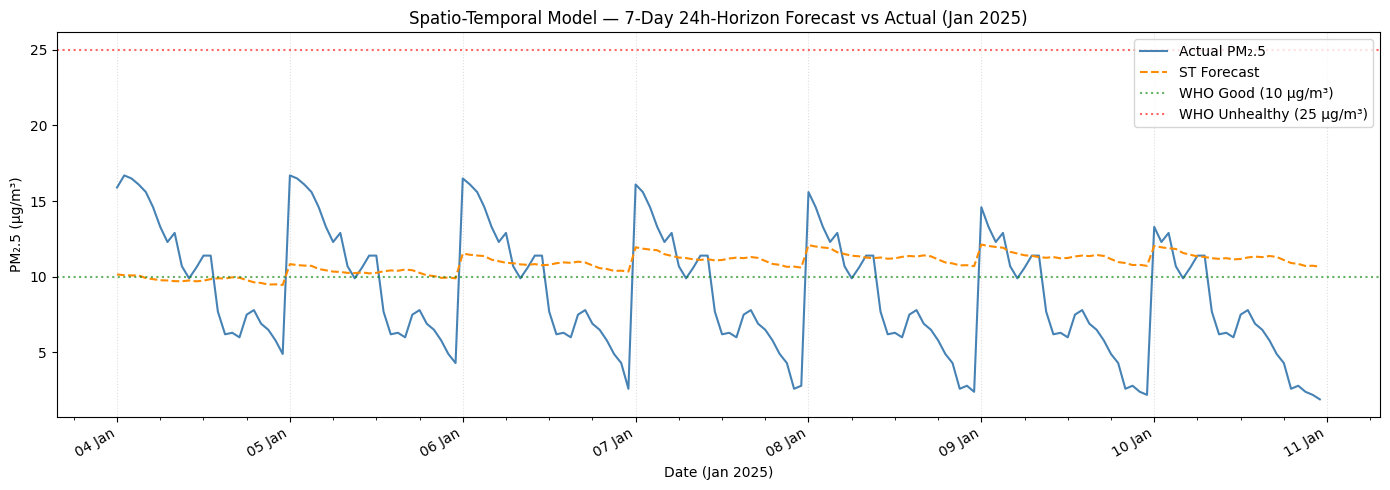

In [19]:
import matplotlib.dates as mdates


test_start_dt = s2_test_raw.index[LOOKBACK]
n_hours_total = len(s2_preds_orig)
dt_index = pd.date_range(start=test_start_dt, periods=n_hours_total, freq='h')

# ── Choose a 7-day window to display ─────────────────────────────────────────
n_plot = min(7 * 24, n_hours_total)
plot_dt    = dt_index[:n_plot]
plot_true  = s2_trues_orig[:n_plot]
plot_pred  = s2_preds_orig[:n_plot]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_dt, plot_true,
        label='Actual PM₂.5', color='steelblue', linewidth=1.5)
ax.plot(plot_dt, plot_pred,
        label='ST Forecast', color='darkorange',
        linestyle='--', linewidth=1.5)
ax.axhline(y=10, color='green', linestyle=':', alpha=0.6, label='WHO Good (10 μg/m³)')
ax.axhline(y=25, color='red',   linestyle=':', alpha=0.6, label='WHO Unhealthy (25 μg/m³)')

# Readable date ticks: one tick per day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax.set_xlabel('Date (Jan 2025)')
ax.set_ylabel('PM₂.5 (μg/m³)')
ax.set_title('Spatio-Temporal Model — 7-Day 24h-Horizon Forecast vs Actual (Jan 2025)')
ax.legend(loc='upper right')
ax.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

## 17. Summary

| Stage | Model | Window | R² | MAE (μg/m³) | RMSE (μg/m³) |
|---|---|---|---|---|---|
| Baseline | Multivariate Transformer-LSTM (4.6) | Jan 2025 | 0.6219 | 2.91 | 3.96 |
| Stage 1 | Traffic-aware spatial encoder | Jul 2017–Apr 2018 | *computed above* | — | — |
| Stage 2 | ST Option B (frozen spatial + weather) | Jan 2025 | *computed above* | — | — |
| Ablation | Stage 2 without spatial prior | Jan 2025 | *computed above* | — | — |

### Thesis Interpretation

If **Stage 2 R² > Ablation R²**: The frozen spatial encoder encodes genuine
structural information about Bath's road topology that improves forecasts even
when no live traffic data is available at inference.

If **Stage 2 R² ≈ Ablation R²**: The spatial prior is not adding signal beyond
what the temporal backbone already captures from weather and PM₂.5 history.
This is still a valid thesis finding — it suggests the locational PM₂.5 dynamics
are dominated by meteorology rather than local traffic topology, supporting the
use of the simpler multivariate model as the MPC backbone.

Either outcome is scientifically meaningful and directly addresses the
*open-system limitation* argument developed in `lstm_results.md`.